In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Datasets/IEOR4578_Forecasting/master_long_hourly_test_2014_05_12.csv"       "/content/master_long_hourly_test_2014_05_12.csv"
!cp "/content/drive/MyDrive/Datasets/IEOR4578_Forecasting/master_long_hourly_train_2012_2013.csv"       "/content/master_long_hourly_train_2012_2013.csv"
!cp "/content/drive/MyDrive/Datasets/IEOR4578_Forecasting/master_long_hourly_validation_2014_01_04.csv" "/content/master_long_hourly_validation_2014_01_04.csv"
!cp "/content/drive/MyDrive/Datasets/IEOR4578_Forecasting/user_cluster_mapping.csv"                    "/content/user_cluster_mapping.csv"

In [3]:
!pip install -q statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.2 MB/s eta 0:00:00


In [4]:
from pathlib import Path

TRAIN_PATH   = '/content/master_long_hourly_train_2012_2013.csv'
VAL_PATH     = '/content/master_long_hourly_validation_2014_01_04.csv'
TEST_PATH    = '/content/master_long_hourly_test_2014_05_12.csv'
MAPPING_PATH = '/content/user_cluster_mapping.csv'

SEASON_LENGTH  = 24    # daily seasonality (hourly data)
LOOKBACK_HOURS = 672   # 4-week lookback window
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# Fixed test-period boundaries (1464 hours each)
TEST_PERIODS = [
    {'period_id': 1, 'label': 'Late Spring',     'start': '2014-05-01', 'end': '2014-06-30'},
    {'period_id': 2, 'label': 'Summer',           'start': '2014-07-01', 'end': '2014-08-30'},
    {'period_id': 3, 'label': 'Early Fall',       'start': '2014-08-31', 'end': '2014-10-31'},
    {'period_id': 4, 'label': 'Late Fall/Winter', 'start': '2014-11-01', 'end': '2014-12-31'},
]

PRED_COL = 'AutoARIMA'

In [5]:
import warnings, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

## 1. Load Data

In [6]:
def load_split(path):
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df = df.rename(columns={'client_id': 'unique_id', 'timestamp': 'ds'})
    return df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

def apply_lookback(df, hours):
    """Keep only the last `hours` rows per client."""
    return (df.groupby('unique_id', group_keys=False)
              .tail(hours)
              .reset_index(drop=True))

train = load_split(TRAIN_PATH)
val   = load_split(VAL_PATH)
test  = load_split(TEST_PATH)

train = apply_lookback(train, LOOKBACK_HOURS)

print(f"train : {train.shape}  {train['ds'].min()} to {train['ds'].max()}")
print(f"val   : {val.shape}    {val['ds'].min()} to {val['ds'].max()}")
print(f"test  : {test.shape}   {test['ds'].min()} to {test['ds'].max()}")

train : (104832, 3)  2013-12-04 00:00:00 to 2013-12-31 23:00:00
val   : (445536, 3)    2014-01-01 00:00:00 to 2014-04-30 23:00:00
test  : (913536, 3)   2014-05-01 00:00:00 to 2014-12-31 23:00:00


## 2. Cluster Mapping & Aggregation

Users within each cluster are **averaged into one representative series** per cluster.  
Outlier users (cluster\_id == -1) are kept as **individual series**, each with its own model.

In [7]:
mapping       = pd.read_csv(MAPPING_PATH)
cluster_map   = mapping[mapping['cluster_id'] != -1].set_index('user_id')['cluster_id']
outlier_users = mapping[mapping['cluster_id'] == -1]['user_id'].tolist()

print(f"Regular clusters : {sorted(cluster_map.unique())}")
print(f"Outlier users    : {len(outlier_users)} users")
print()
for cid, grp in cluster_map.groupby(cluster_map):
    print(f"  cluster_{int(cid)}: {len(grp)} users")

Regular clusters : [np.int64(0), np.int64(1)]
Outlier users    : 8 users

  cluster_0: 84 users
  cluster_1: 64 users


In [8]:
def aggregate_to_clusters(df, cluster_map, outlier_users):
    """Average all users in a cluster into one series per cluster.
    Outlier users are kept as individual series.
    """
    rows = []
    for cluster_id, users in cluster_map.groupby(cluster_map):
        cluster_df = df[df['unique_id'].isin(users.index.tolist())]
        agg = (
            cluster_df
            .groupby('ds')[['y']]
            .mean()
            .reset_index()
        )
        agg['unique_id'] = f'cluster_{int(cluster_id)}'
        rows.append(agg)
    for user in outlier_users:
        rows.append(df[df['unique_id'] == user].copy())
    return (
        pd.concat(rows, ignore_index=True)
        .sort_values(['unique_id', 'ds'])
        .reset_index(drop=True)
    )


# Compute per-user scale factor relative to cluster mean (training data only)
user_means = train.groupby('unique_id')['y'].mean()
user_proportions = {}
for cluster_id, users in cluster_map.groupby(cluster_map):
    cluster_users = users.index.tolist()
    cluster_mean  = user_means[cluster_users].mean()
    for user in cluster_users:
        user_proportions[user] = float(user_means[user] / cluster_mean)
for user in outlier_users:
    user_proportions[user] = 1.0  # outliers are their own series

train_agg = aggregate_to_clusters(train, cluster_map, outlier_users)
val_agg   = aggregate_to_clusters(val,   cluster_map, outlier_users)
test_agg  = aggregate_to_clusters(test,  cluster_map, outlier_users)

print(f"Training on {train_agg['unique_id'].nunique()} series:")
print(sorted(train_agg['unique_id'].unique()))

Training on 10 series:
['MT_124', 'MT_132', 'MT_156', 'MT_158', 'MT_159', 'MT_161', 'MT_162', 'MT_163', 'cluster_0', 'cluster_1']


## 3. Metric Utilities

In [9]:
def disaggregate(preds_df, user_proportions, cluster_map, outlier_users, pred_col):
    """Scale cluster-level forecasts back to individual user level."""
    rows = []
    for cluster_id, users in cluster_map.groupby(cluster_map):
        cluster_uid = f'cluster_{int(cluster_id)}'
        cluster_fc  = preds_df[preds_df['unique_id'] == cluster_uid][['ds', pred_col]].copy()
        for user in users.index:
            user_fc = cluster_fc.copy()
            user_fc[pred_col]  = user_fc[pred_col] * user_proportions[user]
            user_fc['unique_id'] = user
            rows.append(user_fc)
    for user in outlier_users:
        rows.append(preds_df[preds_df['unique_id'] == user][['unique_id', 'ds', pred_col]].copy())
    return pd.concat(rows, ignore_index=True)


def mape_score(y, yhat):
    """MAPE on 0-100 scale; skips zero / NaN actuals."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    pos = (y > 0) & np.isfinite(y) & np.isfinite(yhat)
    return float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float('nan')


def per_client_metrics(df, pred_col):
    rows = []
    for uid, grp in df.groupby('unique_id'):
        y, yhat = grp['y'].values, grp[pred_col].values
        pos = y > 0
        mse  = np.mean((y - yhat) ** 2)
        mae  = np.mean(np.abs(y - yhat))
        mape = mape_score(y, yhat)
        wape = np.sum(np.abs(y - yhat)) / np.sum(np.abs(y))
        rows.append({'client_id': uid, 'MSE': round(mse,4), 'MAE': round(mae,4),
                     'MAPE': round(mape,4), 'WAPE': round(wape,4)})
    # Overall
    y_all, yhat_all = df['y'].values, df[pred_col].values
    rows.append({'client_id': 'OVERALL',
                 'MSE':  round(np.mean((y_all - yhat_all)**2), 4),
                 'MAE':  round(np.mean(np.abs(y_all - yhat_all)), 4),
                 'MAPE': round(mape_score(y_all, yhat_all), 4),
                 'WAPE': round(np.sum(np.abs(y_all-yhat_all))/np.sum(np.abs(y_all)), 4)})
    return pd.DataFrame(rows)

## 4. Phase 1 — Train on Train Set → Evaluate on Validation Set

One `StatsForecast` instance per cluster/outlier series.  
Cluster forecasts are then disaggregated back to individual user level.

In [10]:
# ── Train AutoARIMA — one model per cluster / outlier series ────────────────
sf_models = {}
for uid in sorted(train_agg['unique_id'].unique()):
    sub     = train_agg[train_agg['unique_id'] == uid][['unique_id', 'ds', 'y']]
    model_i = AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True)
    sf_i    = StatsForecast(models=[model_i], freq='h', n_jobs=1)
    sf_i.fit(sub)
    joblib.dump(sf_i, MODEL_DIR / f'autoarima_val_{uid}.joblib')
    sf_models[uid] = sf_i
    print(f'  Fitted: autoarima_val_{uid}.joblib')

print(f"\nTraining complete. {len(sf_models)} models saved.")

  Fitted: autoarima_val_MT_124.joblib
  Fitted: autoarima_val_MT_132.joblib
  Fitted: autoarima_val_MT_156.joblib
  Fitted: autoarima_val_MT_158.joblib
  Fitted: autoarima_val_MT_159.joblib
  Fitted: autoarima_val_MT_161.joblib
  Fitted: autoarima_val_MT_162.joblib
  Fitted: autoarima_val_MT_163.joblib
  Fitted: autoarima_val_cluster_0.joblib
  Fitted: autoarima_val_cluster_1.joblib

Training complete. 10 models saved.


In [11]:
# ── Validation Forecast ──────────────────────────────────────────────────────
val_preds_list = []
for uid, sf_i in sf_models.items():
    sub_val = val_agg[val_agg['unique_id'] == uid]
    preds_i = sf_i.predict(h=sub_val['ds'].nunique())
    val_preds_list.append(preds_i)

val_preds_agg = pd.concat(val_preds_list, ignore_index=True)
val_preds     = disaggregate(val_preds_agg, user_proportions, cluster_map, outlier_users, PRED_COL)
val_eval      = val[['unique_id', 'ds', 'y']].merge(val_preds, on=['unique_id', 'ds'])

val_metrics = per_client_metrics(val_eval, pred_col=PRED_COL)
print('── Validation Metrics (Out-of-Sample) ──')
print(val_metrics.head(5).to_string(index=False))
print('...')
print(val_metrics.tail(1).to_string(index=False))

── Validation Metrics (Out-of-Sample) ──
client_id       MSE     MAE     MAPE   WAPE
   MT_124 9758.8758 77.7164  33.8461 0.2870
   MT_132  225.7467 12.1202  41.2100 0.7088
   MT_156 1337.6730 30.0115  32.8230 0.3676
   MT_158 1862.8863 37.7304  85.7926 0.5113
   MT_159 1774.7561 39.3452 179.9928 0.7728
...
client_id         MSE     MAE    MAPE   WAPE
  OVERALL 115647.8091 92.6956 19.0085 0.1511


## 5. Phase 2 — Retrain on Train+Val → Evaluate on Test Set

In [12]:
# ── Retrain on train+val ─────────────────────────────────────────────────────
train_val     = pd.concat([train, val], ignore_index=True).sort_values(['unique_id', 'ds'])
train_val     = apply_lookback(train_val, LOOKBACK_HOURS)
train_val_agg = aggregate_to_clusters(train_val, cluster_map, outlier_users)

sf_final_models = {}
for uid in sorted(train_val_agg['unique_id'].unique()):
    sub     = train_val_agg[train_val_agg['unique_id'] == uid][['unique_id', 'ds', 'y']]
    model_i = AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True)
    sf_i    = StatsForecast(models=[model_i], freq='h', n_jobs=1)
    sf_i.fit(sub)
    joblib.dump(sf_i, MODEL_DIR / f'autoarima_final_{uid}.joblib')
    sf_final_models[uid] = sf_i
    print(f'  Fitted: autoarima_final_{uid}.joblib')

# ── Test Forecast ─────────────────────────────────────────────────────────────
test_preds_list = []
for uid, sf_i in sf_final_models.items():
    sub_test = test_agg[test_agg['unique_id'] == uid]
    preds_i  = sf_i.predict(h=sub_test['ds'].nunique())
    test_preds_list.append(preds_i)

test_preds_agg = pd.concat(test_preds_list, ignore_index=True)
test_preds     = disaggregate(test_preds_agg, user_proportions, cluster_map, outlier_users, PRED_COL)
test_eval      = test[['unique_id', 'ds', 'y']].merge(test_preds, on=['unique_id', 'ds'])

test_metrics = per_client_metrics(test_eval, pred_col=PRED_COL)
print('── Test Metrics ──')
print(test_metrics.tail(1).to_string(index=False))

  Fitted: autoarima_final_MT_124.joblib
  Fitted: autoarima_final_MT_132.joblib
  Fitted: autoarima_final_MT_156.joblib
  Fitted: autoarima_final_MT_158.joblib
  Fitted: autoarima_final_MT_159.joblib
  Fitted: autoarima_final_MT_161.joblib
  Fitted: autoarima_final_MT_162.joblib
  Fitted: autoarima_final_MT_163.joblib
  Fitted: autoarima_final_cluster_0.joblib
  Fitted: autoarima_final_cluster_1.joblib
── Test Metrics ──
client_id         MSE     MAE    MAPE   WAPE
  OVERALL 141250.4875 94.5555 15.3333 0.1381


## 6. Results Summary

In [13]:
# ── [1] Overall Test MAPE ────────────────────────────────────────────────────
print('=' * 60)
print('  [1] OVERALL TEST MAPE (0-100 scale)')
print('=' * 60)
overall_mape = mape_score(test_eval['y'].values, test_eval[PRED_COL].values)
print(f'  {PRED_COL}  MAPE = {overall_mape:.3f}')

# ── [2] MAPE by Period ────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('  [2] TEST MAPE BY PERIOD (0-100 scale)')
print('=' * 70)
print(f"{'Period':<10} {'Label':<20} {'Date Range':<28} {'MAPE':>8}")
print('-' * 70)
box_data_period, box_labels_period = [], []
for p in TEST_PERIODS:
    s = pd.Timestamp(p['start'])
    e = pd.Timestamp(p['end']) + pd.Timedelta(hours=23)
    sub = test_eval[(test_eval['ds'] >= s) & (test_eval['ds'] <= e)]
    m   = mape_score(sub['y'].values, sub[PRED_COL].values)
    # per-user for box plot
    per_u = []
    for _, grp in sub.groupby('unique_id'):
        per_u.append(mape_score(grp['y'].values, grp[PRED_COL].values))
    box_data_period.append([x for x in per_u if not np.isnan(x)])
    box_labels_period.append(f"P{p['period_id']}: {p['label']}\n{p['start']} to {p['end']}")
    print(f"  Period {p['period_id']:<4} {p['label']:<20} {p['start']} to {p['end']}   {m:>8.3f}")

# ── [3] MAPE by Cluster ───────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('  [3] TEST MAPE BY CLUSTER (0-100 scale)')
print('=' * 70)
user_to_cluster = {}
for cluster_id, users in cluster_map.groupby(cluster_map):
    for user in users.index:
        user_to_cluster[user] = f'cluster_{int(cluster_id)}'
for user in outlier_users:
    user_to_cluster[user] = 'outliers'

cluster_labels_list = sorted(set(user_to_cluster.values()))
box_data_cluster = []
per_user_mapes = {}
for uid, grp in test_eval.groupby('unique_id'):
    per_user_mapes[uid] = mape_score(grp['y'].values, grp[PRED_COL].values)

print(f"  {'Cluster':<20} {'N_users':>8} {'MAPE':>10}")
print('-' * 42)
for label in cluster_labels_list:
    users_in = [u for u, c in user_to_cluster.items() if c == label]
    sub = test_eval[test_eval['unique_id'].isin(users_in)]
    m   = mape_score(sub['y'].values, sub[PRED_COL].values)
    mapes_u = [per_user_mapes[u] for u in users_in if u in per_user_mapes and not np.isnan(per_user_mapes.get(u, float('nan')))]
    box_data_cluster.append(mapes_u)
    print(f"  {label:<20} {len(users_in):>8} {m:>10.3f}")

  [1] OVERALL TEST MAPE (0-100 scale)
  AutoARIMA  MAPE = 15.333

  [2] TEST MAPE BY PERIOD (0-100 scale)
Period     Label                Date Range                       MAPE
----------------------------------------------------------------------
  Period 1    Late Spring          2014-05-01 to 2014-06-30     14.067
  Period 2    Summer               2014-07-01 to 2014-08-30     15.990
  Period 3    Early Fall           2014-08-31 to 2014-10-31     15.205
  Period 4    Late Fall/Winter     2014-11-01 to 2014-12-31     16.087

  [3] TEST MAPE BY CLUSTER (0-100 scale)
  Cluster               N_users       MAPE
------------------------------------------
  cluster_0                  84     14.972
  cluster_1                  64     13.036
  outliers                    8     38.857


## 7. Error Distribution — Box Plots

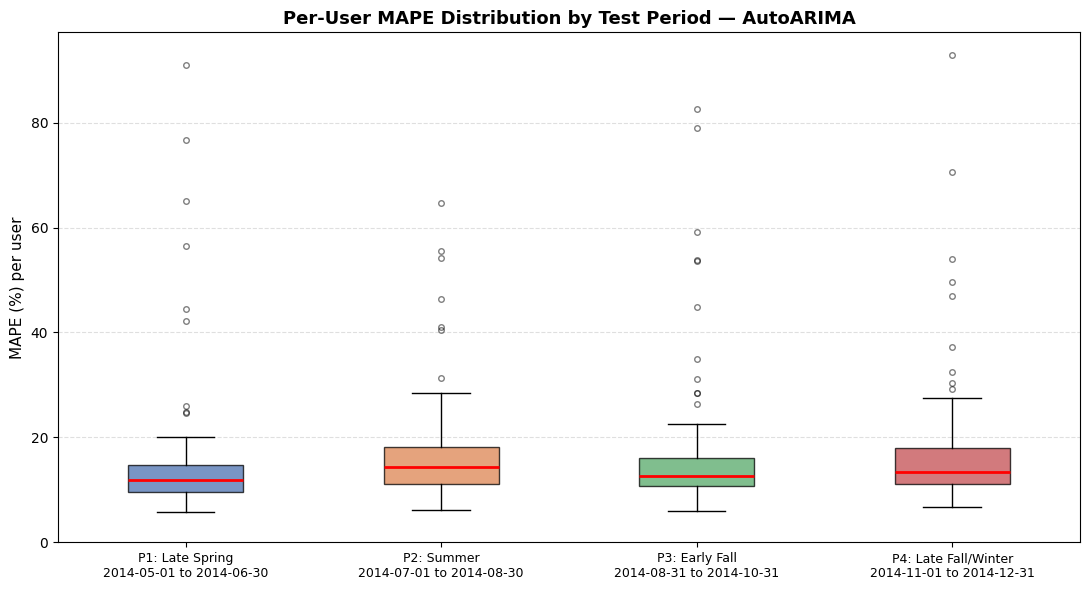

Saved: AutoARIMA_Boxplot_Period.png


In [14]:
# ── Box Plot 1: Per-User MAPE by Test Period ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(
    box_data_period,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(TEST_PERIODS) + 1))
ax.set_xticklabels(box_labels_period, fontsize=9)
ax.set_ylabel('MAPE (%) per user', fontsize=11)
ax.set_title(f'Per-User MAPE Distribution by Test Period — {PRED_COL}', fontsize=13, fontweight='bold')
ax.set_ylim(bottom=0)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / f'AutoARIMA_Boxplot_Period.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: AutoARIMA_Boxplot_Period.png')

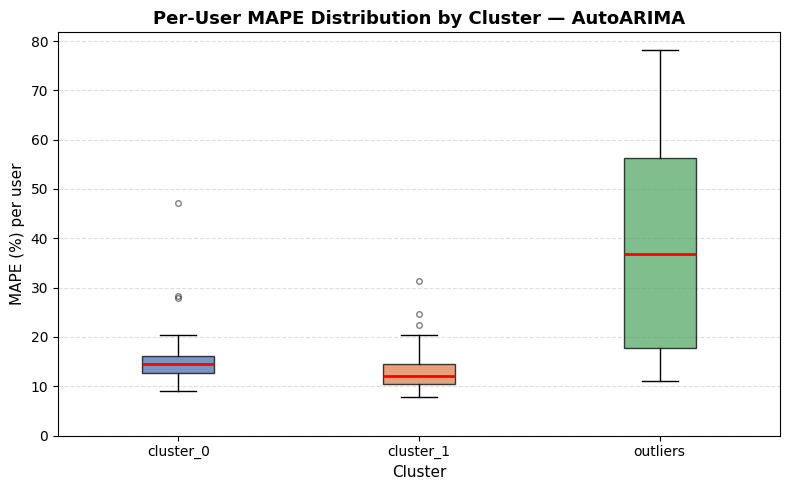

Saved: AutoARIMA_Boxplot_Cluster.png


In [15]:
# ── Box Plot 2: Per-User MAPE by Cluster ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    box_data_cluster,
    labels=cluster_labels_list,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title(f'Per-User MAPE Distribution by Cluster — {PRED_COL}', fontsize=13, fontweight='bold')
ax.set_ylabel('MAPE (%) per user', fontsize=11)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / f'AutoARIMA_Boxplot_Cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: AutoARIMA_Boxplot_Cluster.png')

In [16]:
!zip -r AutoARIMA_models.zip models/

from google.colab import files
files.download('AutoARIMA_models.zip')

  adding: models/ (stored 0%)
  adding: models/autoarima_final_MT_163.joblib (deflated 63%)
  adding: models/autoarima_final_MT_159.joblib (deflated 61%)
  adding: models/autoarima_val_MT_132.joblib (deflated 53%)
  adding: models/autoarima_val_cluster_0.joblib (deflated 51%)
  adding: models/autoarima_final_MT_161.joblib (deflated 84%)
  adding: models/autoarima_val_MT_163.joblib (deflated 83%)
  adding: models/autoarima_final_MT_124.joblib (deflated 54%)
  adding: models/autoarima_final_MT_156.joblib (deflated 52%)
  adding: models/autoarima_val_MT_162.joblib (deflated 57%)
  adding: models/AutoARIMA_Boxplot_Period.png (deflated 23%)
  adding: models/autoarima_final_MT_132.joblib (deflated 79%)
  adding: models/autoarima_val_MT_159.joblib (deflated 83%)
  adding: models/autoarima_val_MT_158.joblib (deflated 82%)
  adding: models/autoarima_val_MT_156.joblib (deflated 50%)
  adding: models/autoarima_final_cluster_1.joblib (deflated 48%)
  adding: models/autoarima_val_MT_124.joblib (def

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>